# Initial Feature Engineering Experiment

### Objective
- To evaluate the impact of temporal feature engineering and rolling price normalization on M5 forecasting accuracy

### Hypothesis
- Adding rolling windows of 7 and 28 days will allow the model to capture short and long term trends, reducing the loss compared to a baseline model without temporal features

In [1]:
import os
import gc
import requests
import pandas as pd
import polars as pl
import numpy as np
import lightgbm as lgb
import wandb
from tqdm import tqdm
from wandb.integration.lightgbm import wandb_callback, log_summary

# --- 1. DOWNLOADER ---
def download_m5_data():
    RAW_DATA_DIR = "../data/raw"
    os.makedirs(RAW_DATA_DIR, exist_ok=True)
    urls = [
        "https://huggingface.co/datasets/kashif/M5/resolve/main/sales_train_evaluation.csv",
        "https://huggingface.co/datasets/kashif/M5/resolve/main/calendar.csv",
        "https://huggingface.co/datasets/kashif/M5/resolve/main/sell_prices.csv"
    ]
    for url in urls:
        filename = url.split("/")[-1]
        file_path = os.path.join(RAW_DATA_DIR, filename)
        if os.path.exists(file_path): continue
        response = requests.get(url, stream=True)
        total_size = int(response.headers.get('content-length', 0))
        with open(file_path, "wb") as f, tqdm(total=total_size, unit='B', unit_scale=True, desc=filename) as pbar:
            for data in response.iter_content(chunk_size=1024):
                f.write(data)
                pbar.update(len(data))
    return RAW_DATA_DIR

# Initial Setup
download_m5_data()

ModuleNotFoundError: No module named 'polars'

In [ ]:
def preprocess_m5_pro(add_features=False):
    os.makedirs("data/processed", exist_ok=True)
    print(f"🚀 Preprocessing: {'WITH' if add_features else 'WITHOUT'} feature engineering...")

    # Using Scan to keep memory low
    sales = pl.scan_csv("../data/raw/sales_train_evaluation.csv")
    calendar = pl.scan_csv("../data/raw/calendar.csv")
    prices = pl.scan_csv("../data/raw/sell_prices.csv")

    id_vars = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

    pipeline = (
        sales.unpivot(index=id_vars, variable_name="d", value_name="sales")
        .join(calendar, on="d", how="left")
        .join(prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")
        .with_columns([
            pl.col("sales").cast(pl.Int16),
            pl.col("sell_price").cast(pl.Float32),
            pl.col("d").str.replace("d_", "").cast(pl.Int16),
            *[pl.col(c).cast(pl.Categorical) for c in id_vars if c != "id"]
        ])
    )

    if add_features:
        print("🛠 Adding Rolling Windows... this takes a minute...")
        pipeline = pipeline.with_columns([
            pl.col("sales").shift(28).rolling_mean(window_size=7).over("item_id").alias("roll_mean_7"),
            pl.col("sales").shift(28).rolling_mean(window_size=28).over("item_id").alias("roll_mean_28"),
            (pl.col("sell_price") / pl.col("sell_price").max().over("item_id")).alias("price_norm")
        ])
        # Instead of dropping all nulls immediately, fill price nulls if any
        pipeline = pipeline.filter(pl.col("roll_mean_28").is_not_null())

    filename = "m5_improved.parquet" if add_features else "m5_baseline.parquet"
    path = os.path.join("../data/processed", filename)

    # sink_parquet is better for memory, but collect().write_parquet is safer for Colab persistence
    df = pipeline.collect()
    df.write_parquet(path)

    print(f"✅ Created: {path}")
    print(f"📊 Total Rows Generated: {df.height:,}") # Should be ~58,000,000
    return path

# Run this now!
preprocess_m5_pro(add_features=True)
# Generate both files
preprocess_m5_pro(add_features=False)


🚀 Preprocessing: WITH feature engineering...
🛠 Adding Rolling Windows... this takes a minute...
✅ Created: data/processed/m5_improved.parquet
📊 Total Rows Generated: 59,013,395
🚀 Preprocessing: WITHOUT feature engineering...
✅ Created: data/processed/m5_baseline.parquet
📊 Total Rows Generated: 59,181,090


'data/processed/m5_baseline.parquet'

In [ ]:
def run_experiment(name, use_features):
    features = ['item_id', 'dept_id', 'store_id', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'wday', 'month']
    if use_features:
        features += ['roll_mean_7', 'roll_mean_28', 'price_norm']

    cat_features = ['item_id', 'dept_id', 'store_id']
    path = f"data/processed/m5_{'improved' if use_features else 'baseline'}.parquet"

    print(f"\n📂 Loading {path}...")
    df_pl = pl.read_parquet(path)

    # Dynamic Range Check
    actual_min_d = df_pl["d"].min()
    actual_max_d = df_pl["d"].max()
    print(f"ℹ️ Data range: Day {actual_min_d} to Day {actual_max_d}")

    # Split: Validation is the LAST 28 days available
    split_point = actual_max_d - 28
    train_pl = df_pl.filter(pl.col("d") <= split_point).select(features + ["sales"])
    valid_pl = df_pl.filter(pl.col("d") > split_point).select(features + ["sales"])

    print(f"📊 Training rows: {train_pl.height:,} | Validation rows: {valid_pl.height:,}")
    del df_pl

    # Dataset Creation with RAM optimization
    train_set = lgb.Dataset(train_pl.select(features).to_pandas(),
                            label=train_pl.select("sales").to_series().to_numpy(),
                            categorical_feature=cat_features, free_raw_data=True)
    del train_pl
    gc.collect()

    valid_set = lgb.Dataset(valid_pl.select(features).to_pandas(),
                            label=valid_pl.select("sales").to_series().to_numpy(),
                            reference=train_set, free_raw_data=True)
    del valid_pl
    gc.collect()

    with wandb.init(project="m5-forecasting-lgbm", name=name) as run:
        params = {
            'objective': 'quantile', 'alpha': 0.5, 'metric': 'quantile',
            'learning_rate': 0.05, 'num_leaves': 128, 'verbose': -1,
            'device': 'cpu'
        }

        model = lgb.train(params, train_set, valid_sets=[valid_set], valid_names=['valid'],
                          num_boost_round=1000,
                          callbacks=[lgb.early_stopping(stopping_rounds=30), wandb_callback()])

        best_iter = model.best_iteration if model.best_iteration > 0 else 1000
        model.save_model(f"best_model_{name}.txt", num_iteration=best_iter)
        log_summary(model)

    del train_set, valid_set
    gc.collect()

# --- RUN EXPERIMENTS ---
# run_experiment("V0_Baseline", use_features=False)
run_experiment("V1_Improved", use_features=True)


📂 Loading data/processed/m5_improved.parquet...
ℹ️ Data range: Day 6 to Day 1941
📊 Training rows: 58,159,675 | Validation rows: 853,720


Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[676]	valid's quantile: 0.522272


iteration,▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇██
valid_quantile,█▅▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,676
iteration,705
valid_quantile,0.52227


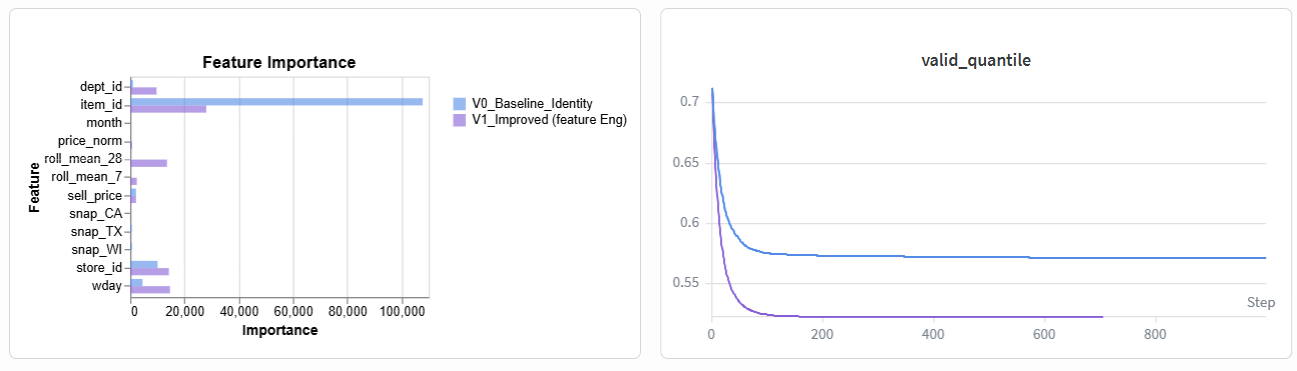

### Key Findings
- Feature engineerign reduced the validation quantile loss from 0.571 to 0.522
- roll_mean_28 emerged as the most significant new predictor, offloading importance from item_id
- Successfully processed 58M rows on limited RAM using Polars and LightGBM's free_raw_data parameter

### Next Steps
- Train 9 seperate models for the uncertainty quantiles using the improved feature set